In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
BASE_DIR = Path.cwd().parent

PROCESSED_PATH = BASE_DIR / "data" / "processed"

nav_history = pd.read_csv(
    PROCESSED_PATH / "02_nav_history_clean.csv"
)

nav_history["date"] = pd.to_datetime(
    nav_history["date"]
)

In [3]:
fund = nav_history[
    nav_history["amfi_code"] == 119551
].copy()

fund = fund.sort_values("date")

fund["daily_return"] = (
    fund["nav"].pct_change()
)

fund = fund.dropna()

fund.head()

,amfi_code,date,nav,daily_return
21851,119551,2022-01-04,54.3474,-0.000702
21852,119551,2022-01-05,54.6869,0.006247
21853,119551,2022-01-06,55.4550,0.014045
21854,119551,2022-01-07,55.3692,-0.001547
21855,119551,2022-01-10,55.2835,-0.001548


In [4]:
mean_return = (
    fund["daily_return"]
    .mean()
)

volatility = (
    fund["daily_return"]
    .std()
)

current_nav = (
    fund["nav"]
    .iloc[-1]
)

print("Mean Return:", mean_return)
print("Volatility:", volatility)
print("Current NAV:", current_nav)

Mean Return: 0.0009167982325947294
Volatility: 0.00865628985637757
Current NAV: 149.3216


In [5]:
n_simulations = 1000

n_days = 252 * 5

simulations = np.zeros(
    (n_days, n_simulations)
)

In [6]:
for i in range(n_simulations):

    prices = [current_nav]

    for j in range(n_days):

        daily_return = np.random.normal(
            mean_return,
            volatility
        )

        next_price = (
            prices[-1]
            * (1 + daily_return)
        )

        prices.append(next_price)

    simulations[:, i] = prices[1:]

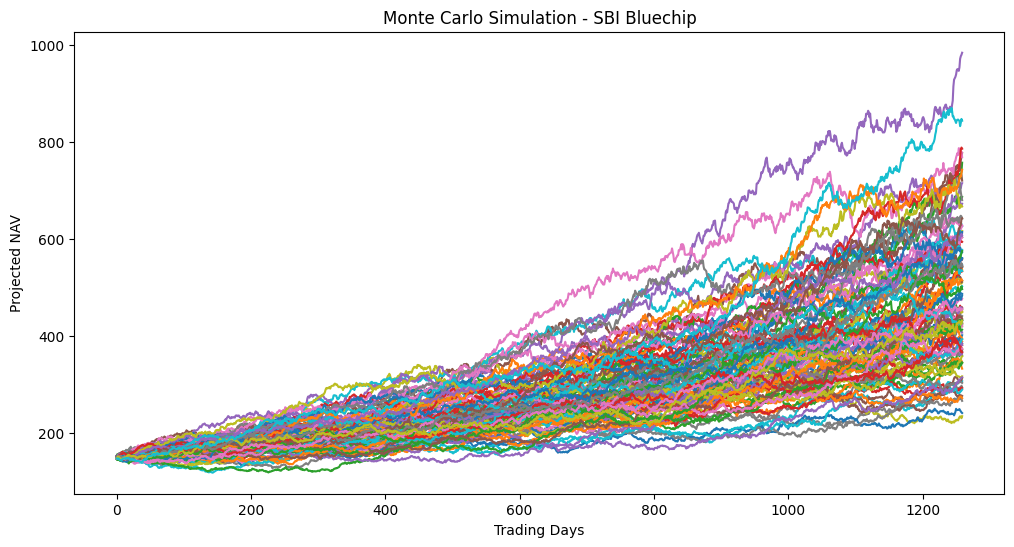

In [7]:
plt.figure(figsize=(12,6))

plt.plot(
    simulations[:, :100]
)

plt.title(
    "Monte Carlo Simulation - SBI Bluechip"
)

plt.xlabel(
    "Trading Days"
)

plt.ylabel(
    "Projected NAV"
)

plt.show()

In [8]:
final_navs = simulations[-1]

print("Number of simulations:", len(final_navs))

Number of simulations: 1000


In [9]:
expected_nav = np.mean(final_navs)

print(
    f"Expected NAV after 5 years: {expected_nav:.2f}"
)

Expected NAV after 5 years: 473.64


In [10]:
best_case = np.percentile(
    final_navs,
    95
)

print(
    f"Best Case NAV (95th percentile): {best_case:.2f}"
)

Best Case NAV (95th percentile): 739.44


In [11]:
worst_case = np.percentile(
    final_navs,
    5
)

print(
    f"Worst Case NAV (5th percentile): {worst_case:.2f}"
)

Worst Case NAV (5th percentile): 271.48


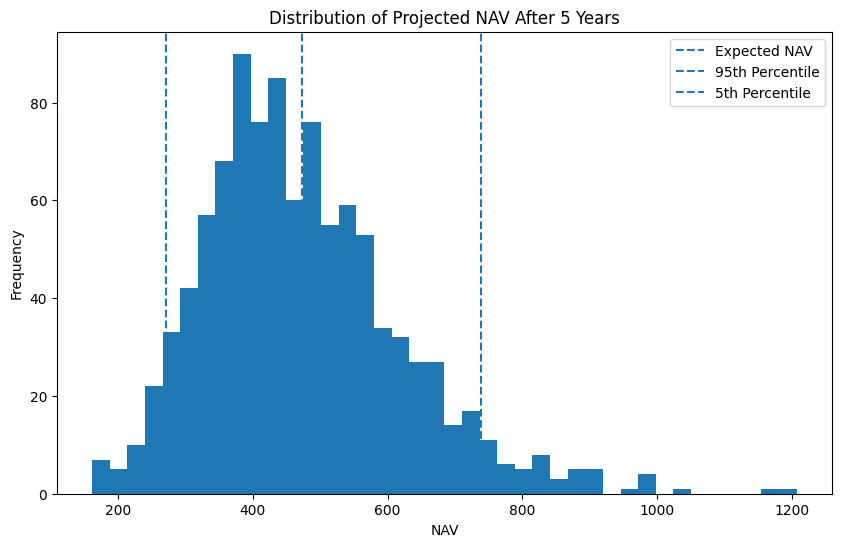

In [12]:
plt.figure(figsize=(10,6))

plt.hist(
    final_navs,
    bins=40
)

plt.axvline(
    expected_nav,
    linestyle="--",
    label="Expected NAV"
)

plt.axvline(
    best_case,
    linestyle="--",
    label="95th Percentile"
)

plt.axvline(
    worst_case,
    linestyle="--",
    label="5th Percentile"
)

plt.legend()

plt.title(
    "Distribution of Projected NAV After 5 Years"
)

plt.xlabel(
    "NAV"
)

plt.ylabel(
    "Frequency"
)

plt.show()

### Monte Carlo Simulation

- 1,000 future NAV paths were simulated using historical return characteristics.
- The simulation horizon was 5 years (1,260 trading days).
- Expected NAV, best-case NAV, and worst-case NAV were estimated.
- The widening spread of paths demonstrates increasing uncertainty over longer horizons.
- Monte Carlo simulation provides a probabilistic view of future fund performance rather than a single forecast.

# Monte Carlo Simulation Results

## Simulation Parameters
- Number of Simulations: 1000
- Forecast Horizon: 5 Years
- Trading Days: 1260

## Results
- Expected NAV after 5 years: 473.64
- Best Case NAV (95th percentile): 739.44
- Worst Case NAV (5th percentile): 271.48

## Interpretation
- The expected outcome suggests significant long-term growth potential.
- The distribution of outcomes highlights uncertainty in future performance.
- Even lower-percentile scenarios indicate positive long-term appreciation.
- Monte Carlo simulation provides a probabilistic forecast rather than a deterministic prediction.

In [13]:
metrics = pd.read_csv(
    "../data/processed/performance_metrics.csv"
)

metrics[
    ["scheme_name", "cagr_pct"]
].head(10)

,scheme_name,cagr_pct
0,ICICI Pru Midcap Fund - Regular - Growth,32.09
1,SBI Small Cap Fund - Regular Plan - Growth,31.55
2,DSP Small Cap Fund - Regular - Growth,31.30
3,Mirae Asset Tax Saver Fund - Regular - Growth,30.43
4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,29.31
5,Mirae Asset Large Cap Fund - Regular - Growth,29.20
6,Kotak Flexicap Fund - Regular - Growth,29.17
7,DSP Midcap Fund - Regular - Growth,28.40
8,Axis Midcap Fund - Regular - Growth,27.20
9,SBI Bluechip Fund - Regular Plan - Growth,24.82


In [24]:
metrics = pd.read_csv(
    "../data/processed/performance_metrics.csv"
)

metrics.head(10)[
    ["amfi_code", "scheme_name", "category", "cagr_pct"]
]

,amfi_code,scheme_name,category,cagr_pct
0,120505,ICICI Pru Midcap Fund - Regular - Growth,Mid Cap,32.09
1,119598,SBI Small Cap Fund - Regular Plan - Growth,Small Cap,31.55
2,149324,DSP Small Cap Fund - Regular - Growth,Small Cap,31.30
3,148569,Mirae Asset Tax Saver Fund - Regular - Growth,ELSS,30.43
4,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Mid Cap,29.31
5,148567,Mirae Asset Large Cap Fund - Regular - Growth,Large Cap,29.20
6,120843,Kotak Flexicap Fund - Regular - Growth,Flexi Cap,29.17
7,149323,DSP Midcap Fund - Regular - Growth,Mid Cap,28.40
8,119094,Axis Midcap Fund - Regular - Growth,Mid Cap,27.20
9,119551,SBI Bluechip Fund - Regular Plan - Growth,Large Cap,24.82


In [25]:
selected_codes = [
    119551,  # SBI Bluechip
    120505,  # ICICI Midcap
    119598,  # SBI Small Cap
    120843,  # Kotak Flexicap
    148569   # Mirae Tax Saver
]

In [26]:
portfolio_nav = nav_history[
    nav_history["amfi_code"].isin(selected_codes)
].copy()

print(portfolio_nav.shape)

(5750, 3)


In [27]:
nav_matrix = portfolio_nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

print(nav_matrix.shape)

nav_matrix.head()

(1150, 5)


amfi_code,119551,119598,120505,120843,148569
date,,,,,
2022-01-03,54.3856,89.8738,135.8720,49.9131,28.8620
2022-01-04,54.3474,88.5495,133.1682,50.8195,29.1038
2022-01-05,54.6869,88.0925,137.2101,50.1942,29.5489
2022-01-06,55.4550,88.5175,136.5355,50.6213,29.5744
2022-01-07,55.3692,91.4235,137.8537,49.9391,29.6091


In [28]:
print(nav_matrix.isnull().sum())

amfi_code
119551    0
119598    0
120505    0
120843    0
148569    0
dtype: int64


In [29]:
returns = nav_matrix.pct_change()

returns = returns.dropna()

print(returns.shape)

returns.head()

(1149, 5)


amfi_code,119551,119598,120505,120843,148569
date,,,,,
2022-01-04,-0.000702,-0.014735,-0.019900,0.018160,0.008378
2022-01-05,0.006247,-0.005161,0.030352,-0.012304,0.015294
2022-01-06,0.014045,0.004824,-0.004917,0.008509,0.000863
2022-01-07,-0.001547,0.032830,0.009655,-0.013477,0.001173
2022-01-10,-0.001548,0.051113,0.000252,-0.002583,0.009372


In [30]:
mean_returns = returns.mean() * 252

cov_matrix = returns.cov() * 252

print(mean_returns)

amfi_code
119551    0.231033
119598    0.302656
120505    0.292653
120843    0.272602
148569    0.283262
dtype: float64


In [31]:
print(mean_returns.shape)

print(cov_matrix.shape)

(5,)
(5, 5)


In [32]:
num_portfolios = 5000

results = np.zeros((3, num_portfolios))

weights_record = []

In [33]:
for i in range(num_portfolios):

    weights = np.random.random(5)

    weights /= np.sum(weights)

    portfolio_return = np.sum(
        mean_returns.values * weights
    )

    portfolio_std = np.sqrt(
        np.dot(
            weights.T,
            np.dot(
                cov_matrix.values,
                weights
            )
        )
    )

    sharpe = (
        portfolio_return - 0.05
    ) / portfolio_std

    results[0, i] = portfolio_return
    results[1, i] = portfolio_std
    results[2, i] = sharpe

    weights_record.append(weights)

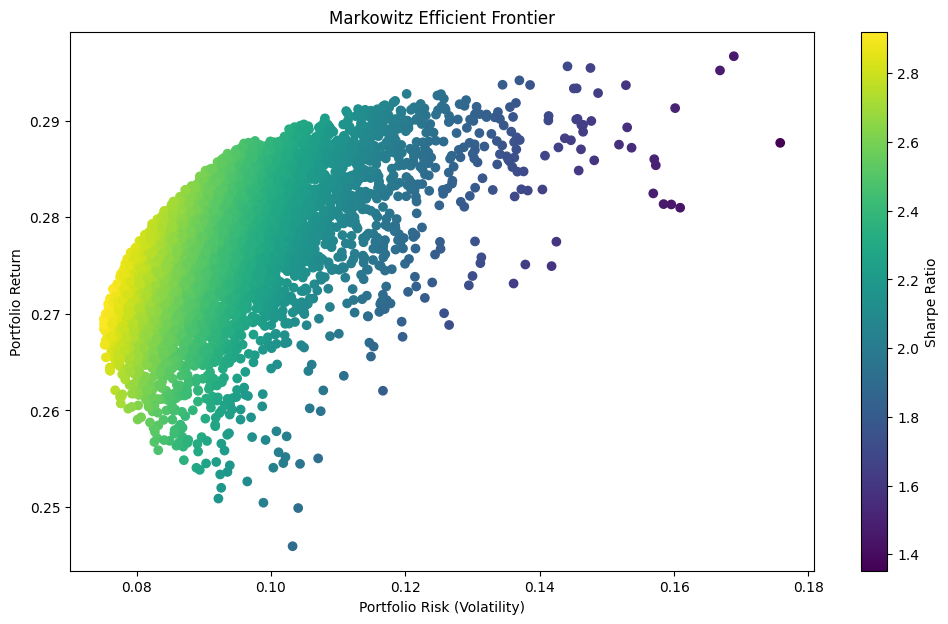

In [34]:
plt.figure(figsize=(12,7))

scatter = plt.scatter(
    results[1],
    results[0],
    c=results[2]
)

plt.colorbar(
    scatter,
    label="Sharpe Ratio"
)

plt.xlabel(
    "Portfolio Risk (Volatility)"
)

plt.ylabel(
    "Portfolio Return"
)

plt.title(
    "Markowitz Efficient Frontier"
)

plt.show()

In [35]:
max_sharpe_idx = np.argmax(
    results[2]
)

best_return = results[0, max_sharpe_idx]
best_risk = results[1, max_sharpe_idx]
best_sharpe = results[2, max_sharpe_idx]

best_weights = weights_record[
    max_sharpe_idx
]

print("Best Return:", round(best_return*100,2), "%")
print("Best Risk:", round(best_risk*100,2), "%")
print("Best Sharpe:", round(best_sharpe,2))

Best Return: 26.94 %
Best Risk: 7.51 %
Best Sharpe: 2.92


In [36]:
allocation = pd.DataFrame({

    "Fund": [
        "SBI Bluechip",
        "SBI Small Cap",
        "ICICI Midcap",
        "Kotak Flexicap",
        "Mirae Tax Saver"
    ],

    "Weight (%)":
    np.round(
        best_weights * 100,
        2
    )

})

allocation

,Fund,Weight (%)
0,SBI Bluechip,28.04
1,SBI Small Cap,10.25
2,ICICI Midcap,17.00
3,Kotak Flexicap,25.82
4,Mirae Tax Saver,18.89


# Markowitz Portfolio Optimization

## Objective

Construct an optimal portfolio using five diversified mutual funds.

## Selected Funds

- SBI Bluechip Fund
- SBI Small Cap Fund
- ICICI Pru Midcap Fund
- Kotak Flexicap Fund
- Mirae Asset Tax Saver Fund

## Results

### Optimal Allocation

| Fund | Weight (%) |
|--------|--------:|
| SBI Bluechip | 28.04 |
| SBI Small Cap | 10.25 |
| ICICI Midcap | 17.00 |
| Kotak Flexicap | 25.82 |
| Mirae Tax Saver | 18.89 |

### Portfolio Statistics

- Expected Return: 26.94%
- Portfolio Volatility: 7.51%
- Sharpe Ratio: 2.92

## Insights

- The optimized portfolio achieved a high expected return with relatively low volatility.
- Large-cap and flexicap funds received the highest allocations.
- Small-cap exposure was limited despite strong returns due to higher risk.
- Portfolio diversification improved risk-adjusted performance.